In [3]:
# Import various libraries 

import numpy as np
import astropy
import photutils
import ccdproc
from ccdproc import CCDData, combiner
from astropy import units as u
import astropy.io.fits as fits
from astropy.io import ascii
import time
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from photutils.centroids import centroid_com, centroid_1dg, centroid_2dg
from photutils.aperture import CircularAperture, CircularAnnulus
from photutils.aperture import aperture_photometry
from photutils.background import Background2D
from photutils.background import MedianBackground
from photutils.detection import DAOStarFinder
from photutils.segmentation  import detect_sources, deblend_sources, SourceCatalog
from scipy.ndimage import shift
import gc                               
import pandas as pd
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia # this library is used to query astronomical databases 
from photutils.segmentation import SourceCatalog, SegmentationImage
from scipy.spatial import cKDTree

# Calibrating and Cataloguing Green-band

In [37]:
g_combined = CCDData.read("g_NGC_2547_cropped.fits", unit="adu")
print("Loaded g_combined successfully")

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Loaded g_combined successfully


In [29]:
from astroquery.astrometry_net import AstrometryNet
from astropy.io import fits

ast = AstrometryNet()
ast.api_key = 'rahhejaruebqmxrg'  # Get from nova.astrometry.net

# Submit image for plate solving
wcs_header = ast.solve_from_image('g_NGC_2547_cropped.fits', force_image_upload=True)

# Add WCS to original FITS file
with fits.open('g_NGC_2547_cropped.fits', mode='update') as hdul:
    hdul[0].header.update(wcs_header)
    hdul.flush()

print("WCS added successfully!")

Solving.........WCS added successfully!


In [5]:
scim=CCDData.read("g_NGC_2547_cropped.fits", unit="adu")   # Read the image

w = scim.wcs                                      # Read the World Coordinate System
print(w)

med=np.median(scim.data)                          # Median pixel value
scim.data=scim.data-med                           # Use the median for the sky subtraction
mean, median, std = astropy.stats.sigma_clipped_stats(scim.data, sigma=3.0, maxiters=5)    
print('Image stats (mean, median and standard deviation):', mean,median,std)

segimage=detect_sources(scim.data, 2.00*std, 9, connectivity=4, mask=None)

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please app

/opt/homebrew/Caskroom/miniforge/base/envs/obsastro2024/lib/python3.9/site-packages/astropy/wcs/wcs.py:3124: RuntimeWarning: cdelt will be ignored since cd is present
  description.append(s.format(*self.wcs.cdelt))


In [7]:
outfile="segimage_g.fits"                # Set the output file name
hdu=fits.PrimaryHDU(segimage)          # Define a FITS header for this data
# Convert WCS to header format
wcsheader = w.to_header(relax=True)
hdu.header.extend(wcsheader)
hdu.writeto(outfile, overwrite=True)   # Write the output and overwrite existing files if needed. 


INFO: 
        Inconsistent SIP distortion information is present in the current WCS:
        SIP coefficients were detected, but CTYPE is missing "-SIP" suffix,
        therefore the current WCS is internally inconsistent.

        Because relax has been set to True, the resulting output WCS will have
        "-SIP" appended to CTYPE in order to make the header internally consistent.

        However, this may produce incorrect astrometry in the output WCS, if
        in fact the current WCS is already distortion-corrected.

        Therefore, if current WCS is already distortion-corrected (eg, drizzled)
        then SIP distortion components should not apply. In that case, for a WCS
        that is already distortion-corrected, please remove the SIP coefficients
        from the header.

         [astropy.wcs.wcs]


In [52]:
# ── Load image and build source catalogue ─────────────────────────────────────
with fits.open('g_NGC_2547_cropped.fits') as hdul:
    sci_data   = hdul[0].data.astype(float).copy()
    sci_header = hdul[0].header

with fits.open('segimage_g.fits') as hdul:
    seg_data = hdul[0].data.copy()

w = WCS(sci_header)
sci_data -= np.median(sci_data)
_, _, std = astropy.stats.sigma_clipped_stats(sci_data, sigma=3.0, maxiters=5)

segmap       = SegmentationImage(seg_data)
source_table = SourceCatalog(sci_data, segmap, wcs=w)

# ── Aperture photometry on all detected sources ───────────────────────────────
positions = []
for obj in source_table:
    positions.append((obj.centroid[0], obj.centroid[1]))

apertures  = CircularAperture(positions, r=8.3)
phot_table = aperture_photometry(sci_data, apertures)

print("\nFirst 10 rows of photometry table:")
print(phot_table[:10])
print("\nColumn names:", phot_table.colnames)

# ── Gaia query ────────────────────────────────────────────────────────────────
ra_field  = 122.353125759
dec_field = -48.8904062838

coord  = SkyCoord(ra=ra_field, dec=dec_field, unit='deg', frame='icrs')
radius = u.Quantity(0.25, u.deg)

Gaia.ROW_LIMIT = 5000
print("\nQuerying Gaia DR3...")
j = Gaia.cone_search(coordinate=coord, radius=radius)


r = j.get_results()

mask = (r['phot_g_mean_mag']  > 0) & (r['phot_g_mean_mag']  < 30) & \
       (r['phot_bp_mean_mag'] > 0) & (r['phot_bp_mean_mag'] < 30) & \
       (r['phot_rp_mean_mag'] > 0) & (r['phot_rp_mean_mag'] < 30)
r = r[mask]
r.sort('phot_g_mean_mag')

nrows, ncols = sci_data.shape
gaia_coords  = SkyCoord(ra=r['ra'], dec=r['dec'], unit='deg', frame='icrs')
px, py       = w.world_to_pixel(gaia_coords)

in_image = (px > 20) & (px < ncols-20) & (py > 20) & (py < nrows-20)
r  = r[in_image]
px = px[in_image]
py = py[in_image]
print(f"Gaia sources inside image footprint: {len(r)}")

# ── Match each Gaia star to nearest source in phot_table ─────────────────────
phot_x = np.array(phot_table['xcenter'])
phot_y = np.array(phot_table['ycenter'])

print(" Reference stars (G < 12)")
print(f"{'#':<4} {'RA':>12} {'Dec':>12} {'G_BP':>6} {'G':>6} {'G_RP':>6}  "
      f"{'x_pix':>7} {'y_pix':>7}  {'dist':>5} {'aperture_sum':>14}")
print("-" * 90)
count = 0
for i in range(len(r)):
    if r['phot_g_mean_mag'][i] < 12:
        dists      = np.sqrt((phot_x - px[i])**2 + (phot_y - py[i])**2)
        nearest    = int(np.argmin(dists))
        flux       = phot_table['aperture_sum'][nearest]
        print(f"{count:<4} {r['ra'][i]:>12.5f} {r['dec'][i]:>12.5f} "
              f"{r['phot_bp_mean_mag'][i]:>6.3f} {r['phot_g_mean_mag'][i]:>6.3f} "
              f"{r['phot_rp_mean_mag'][i]:>6.3f}  {px[i]:>7.1f} {py[i]:>7.1f}  "
              f"{dists[nearest]:>5.1f} {flux:>14.1f}")
        count += 1
        if count >= 60:   # added
            break

print("Faint stars (15 < G < 18)")  # was 14 < G < 17
print(f"{'#':<4} {'RA':>12} {'Dec':>12} {'G_BP':>6} {'G':>6} {'G_RP':>6}  "
      f"{'x_pix':>7} {'y_pix':>7}  {'dist':>5} {'aperture_sum':>14}")
print("-" * 90)
count = 0
for i in range(len(r)):
    g = r['phot_g_mean_mag'][i]
    if 15 < g < 18:                     # was 14 < g < 17
        dists   = np.sqrt((phot_x - px[i])**2 + (phot_y - py[i])**2)
        nearest = int(np.argmin(dists))
        flux    = phot_table['aperture_sum'][nearest]
        print(f"{count:<4} {r['ra'][i]:>12.5f} {r['dec'][i]:>12.5f} "
              f"{r['phot_bp_mean_mag'][i]:>6.3f} {g:>6.3f} "
              f"{r['phot_rp_mean_mag'][i]:>6.3f}  {px[i]:>7.1f} {py[i]:>7.1f}  "
              f"{dists[nearest]:>5.1f} {flux:>14.1f}")
        count += 1
        if count >= 60:
            break

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]

First 10 rows of ph

In [53]:
# Gaia DR3 → Johnson V transformation
# Using Gaia DR3 documentation (Riello et al. 2021)
# V = G + a0 + a1*(GBP-GRP) + a2*(GBP-GRP)^2 + a3*(GBP-GRP)^3
# Valid for GBP-GRP in range 0.0 to 2.5       


a0 = -0.02704
a1 =  0.01424
a2 = -0.2156
a3 =  0.01426

def gaia_to_V(G, G_BP, G_RP):
    colour = G_BP - G_RP
    V = G + a0 + a1*colour + a2*colour**2 + a3*colour**3
    return V

# ── Reference star ────────────────────────────────────────────────────────────
G_BP_ref = 10.787
G_ref    = 10.702
G_RP_ref = 10.568
F_ref    = 92857.5

# ── Faint star ────────────────────────────────────────────────────────────────
  
G_BP_faint = 15.824
G_faint    = 15.063
G_RP_faint = 14.214 
F_faint    = 1679.1   

V_ref        = gaia_to_V(G_ref,   G_BP_ref,   G_RP_ref)
V_faint_gaia = gaia_to_V(G_faint, G_BP_faint, G_RP_faint)

print("Reference Star")
print(f"  GBP-GRP colour:         {G_BP_ref - G_RP_ref:.3f}")
print(f"  Calibrated V magnitude: {V_ref:.3f}")
print(f"  Measured flux (F_ref):  {F_ref:.1f} ADU")

print("\n Faint Star")
print(f"  GBP-GRP colour:              {G_BP_faint - G_RP_faint:.3f}")
print(f"  Gaia-calibrated V magnitude: {V_faint_gaia:.3f}")
print(f"  Measured flux:               {F_faint:.1f} ADU")

# ── Sanity check ──────────────────────────────────────────────────────────────
V_faint_measured = V_ref - 2.5 * np.log10(F_faint / F_ref)

print("\n Sanity Check")
print(f"  V (from image photometry): {V_faint_measured:.3f}")
print(f"  V (from Gaia DR3 formula): {V_faint_gaia:.3f}")
print(f"  Difference:                {abs(V_faint_measured - V_faint_gaia):.3f} mag")
if abs(V_faint_measured - V_faint_gaia) < 0.5:
    print("  Good agreement")
else:
    print("  Large discrepancy")

Reference Star
  GBP-GRP colour:         0.219
  Calibrated V magnitude: 10.668
  Measured flux (F_ref):  92857.5 ADU

 Faint Star
  GBP-GRP colour:              1.610
  Gaia-calibrated V magnitude: 14.560
  Measured flux:               1679.1 ADU

 Sanity Check
  V (from image photometry): 15.025
  V (from Gaia DR3 formula): 14.560
  Difference:                0.465 mag
  Good agreement


Reference Star
  Johnson V:          10.668
  SeeStar Green:      10.664
  Net flux:           67431.9 ADU
  Background/pixel:   53.408 ADU

=== Calibration Summary ===
  Total sources:         1028
  Valid V magnitudes:    998
  Magnitude range:       6.82 to 21.58

  idx        x        y     raw_flux    Green    V_mag
-------------------------------------------------------
    0    57.03     2.31       3476.0   13.884   13.933
    1   229.27     1.03     154112.9    9.767    9.816
    2   261.54     0.63       3465.1   13.887   13.936
    3   425.19     0.48       2272.8   14.345   14.394
    4   443.63     0.64       2170.3   14.395   14.444
    5   487.14     0.40        624.5   15.748   15.797
    6   792.19     1.68       3259.4   13.954   14.003
    7   984.66     0.46        525.0   15.936   15.985
    8     4.88     3.09        459.3   16.081   16.130
    9   407.20     4.28       1717.3   14.649   14.698
   10   580.27     4.28        958.6   15.282   15.331
   11   678.62  

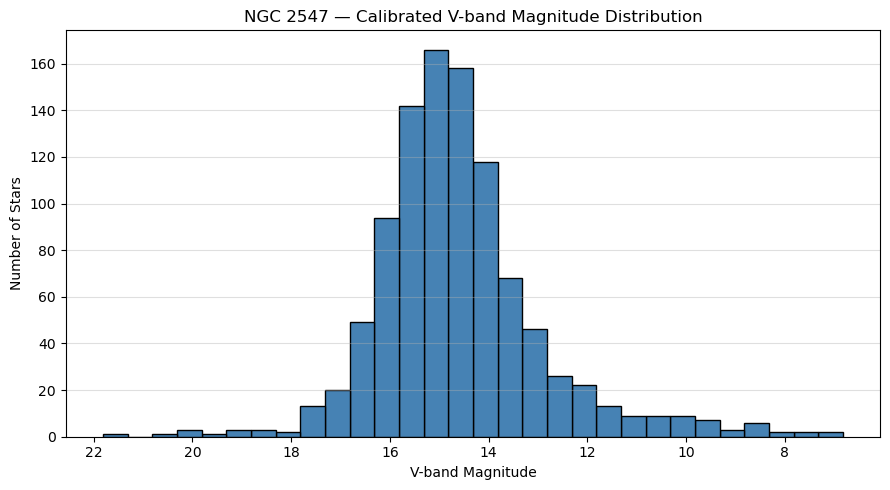

In [14]:
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
import numpy as np

# ── Helper functions ──────────────────────────────────────────────────────────
def net_flux(data, pos, r_ap=8.3, r_in=25, r_out=40):
    
    aperture    = CircularAperture([pos], r=r_ap)
    annulus     = CircularAnnulus([pos], r_in=r_in, r_out=r_out)
    phot        = aperture_photometry(data, aperture)
    bkg_phot    = aperture_photometry(data, annulus)
    bkg_per_pix = bkg_phot['aperture_sum'][0] / annulus.area
    flux_net    = phot['aperture_sum'][0] - bkg_per_pix * aperture.area
    return flux_net, bkg_per_pix

def gaia_to_V(G, G_BP, G_RP):
    
    a0, a1, a2, a3 = -0.02704, 0.01424, -0.2156, 0.01426
    return G + a0 + a1*(G_BP-G_RP) + a2*(G_BP-G_RP)**2 + a3*(G_BP-G_RP)**3

def BV_from_gaia(G_BP, G_RP):
    
    return 1.35 * (G_BP - G_RP) - 0.10

def V_to_seestar_green(V, G_BP, G_RP):
    
    BV = BV_from_gaia(G_BP, G_RP)
    return V - 0.07 * BV + 0.01

def seestar_green_to_V(green, G_BP, G_RP):
    
    BV = BV_from_gaia(G_BP, G_RP)
    return green + 0.07 * BV - 0.01

# Reference star
G_BP_ref, G_ref, G_RP_ref = 10.787, 10.702, 10.568
x_ref, y_ref               = 560.6, 90.4

V_ref_johnson  = gaia_to_V(G_ref, G_BP_ref, G_RP_ref)
green_ref      = V_to_seestar_green(V_ref_johnson, G_BP_ref, G_RP_ref)
F_ref, bkg_ref = net_flux(sci_data, (x_ref, y_ref))

print("Reference Star")
print(f"  Johnson V:          {V_ref_johnson:.3f}")
print(f"  SeeStar Green:      {green_ref:.3f}")
print(f"  Net flux:           {F_ref:.1f} ADU")
print(f"  Background/pixel:   {bkg_ref:.3f} ADU")

# Calibrate all sources
maglist   = []   # Calibrated V magnitudes
greenlist = []   # SeeStar Green magnitudes (before V correction)

for obj in phot_table:
    flux_raw = obj['aperture_sum']
    if flux_raw > 0 and F_ref > 0:
        green_mag = green_ref - 2.5 * np.log10(flux_raw / F_ref)
        greenlist.append(green_mag)
        # For V conversion we don't have Gaia colours for every source,
        # so assume a typical cluster star colour (GBP-GRP ~ 0.7, BV ~ 0.85)
        # This is a reasonable approximation for NGC 2547 FGK members
        green_to_V_offset = 0.07 * (1.35 * 0.7 - 0.10) - 0.01   # = +0.047
        maglist.append(green_mag + green_to_V_offset)
    else:
        greenlist.append(np.nan)
        maglist.append(np.nan)

maglist   = np.array(maglist)
greenlist = np.array(greenlist)

# Summary statistics
valid = maglist[np.isfinite(maglist) & (maglist > 0) & (maglist < 25)]
print(f"\n=== Calibration Summary ===")
print(f"  Total sources:         {len(maglist)}")
print(f"  Valid V magnitudes:    {len(valid)}")
print(f"  Magnitude range:       {valid.min():.2f} to {valid.max():.2f}")

# Print first 20 results 
print(f"\n{'idx':>5} {'x':>8} {'y':>8} {'raw_flux':>12} {'Green':>8} {'V_mag':>8}")
print("-" * 55)
for i in range(min(20, len(phot_table))):
    print(f"{i:>5} {phot_table['xcenter'][i].value:>8.2f} "
          f"{phot_table['ycenter'][i].value:>8.2f} "
          f"{phot_table['aperture_sum'][i]:>12.1f} "
          f"{greenlist[i]:>8.3f} {maglist[i]:>8.3f}")

# Histogram of calibrated V magnitudes
import matplotlib.pyplot as plt

bin_edges = np.arange(np.nanmin(valid), np.nanmax(valid) + 0.5, 0.5)

plt.figure(figsize=(9, 5))
plt.hist(valid, bins=bin_edges, edgecolor='black', color='steelblue')
plt.xlabel('V-band Magnitude')
plt.ylabel('Number of Stars')
plt.title('NGC 2547 — Calibrated V-band Magnitude Distribution')
plt.gca().invert_xaxis()
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig("calibrated_V_band_magnitude.png", dpi=300, bbox_inches="tight")
plt.show()



In [15]:
import pandas as pd
import numpy as np

# Create a dataframe from the results
df = pd.DataFrame({
    "x": phot_table['xcenter'].value,
    "y": phot_table['ycenter'].value,
    "raw_flux": phot_table['aperture_sum'],
    "Green": greenlist,
    "V_mag": maglist
})

# Optional: remove NaN magnitudes
df = df.replace([np.inf, -np.inf], np.nan)

# Save to CSV
df.to_csv("maglist_V_catalog.csv", index=False)

print("CSV saved as maglist_V_catalog.csv")

CSV saved as maglist_V_catalog.csv


# Calibrating and Cataloguing Blue band  

In [ ]:
from astroquery.astrometry_net import AstrometryNet
from astropy.io import fits

ast = AstrometryNet()
ast.api_key = 'rahhejaruebqmxrg'  # Get from nova.astrometry.net

# Submit image for plate solving
wcs_header = ast.solve_from_image('b_NGC_2547_cropped.fits', force_image_upload=True)

# Add WCS to original FITS file
with fits.open('b_NGC_2547_cropped.fits', mode='update') as hdul:
    hdul[0].header.update(wcs_header)
    hdul.flush()

print("WCS added successfully!")

In [8]:
scim=CCDData.read("b_NGC_2547_cropped.fits", unit="adu")   # Read the image

w = scim.wcs                                      # Read the World Coordinate System
print(w)

med=np.median(scim.data)                          # Median pixel value
scim.data=scim.data-med                           # Use the median for the sky subtraction
mean, median, std = astropy.stats.sigma_clipped_stats(scim.data, sigma=3.0, maxiters=5)    
print('Image stats (mean, median and standard deviation):', mean,median,std)

segimage=detect_sources(scim.data, 2.00*std, 9, connectivity=4, mask=None)

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 122.353012059 -48.890307616 
CRPIX : 587.701370239 -116.960914612 
PC1_1 PC1_2  : -0.00059571549556 0.000280968298695 
PC2_1 PC2_2  : -0.000281013114939 -0.000595651847387 
CDELT : 1.0 1.0 
NAXIS : 1080  700
Image stats (mean, median and standard deviation): -0.27016326785087585 -0.5429936647415161 8.240755081176758


/opt/homebrew/Caskroom/miniforge/base/envs/obsastro2024/lib/python3.9/site-packages/astropy/wcs/wcs.py:3124: RuntimeWarning: cdelt will be ignored since cd is present
  description.append(s.format(*self.wcs.cdelt))


In [9]:
outfile="segimage_b.fits"                # Set the output file name
hdu=fits.PrimaryHDU(segimage)          # Define a FITS header for this data
# Convert WCS to header format
wcsheader = w.to_header(relax=True)
hdu.header.extend(wcsheader)
hdu.writeto(outfile, overwrite=True)   # Write the output and overwrite existing files if needed. 


In [10]:
#  Load B-band image and build source catalogue 
with fits.open('b_NGC_2547_cropped.fits') as hdul:  
    sci_data   = hdul[0].data.astype(float).copy()
    sci_header = hdul[0].header

with fits.open('segimage_b.fits') as hdul:
    seg_data = hdul[0].data.copy()

w = WCS(sci_header)
sci_data -= np.median(sci_data)
_, _, std = astropy.stats.sigma_clipped_stats(sci_data, sigma=3.0, maxiters=5)

segmap       = SegmentationImage(seg_data)
source_table = SourceCatalog(sci_data, segmap, wcs=w)

#Aperture photometry on all detected sources
positions = []
valid_sources = []   # keep track of which sources had valid centroids

for obj in source_table:
    x, y = obj.centroid[0], obj.centroid[1]
    if np.isfinite(x) and np.isfinite(y):   # skip NaN centroids
        positions.append((x, y))
        valid_sources.append(obj)

print(f"Total sources in segmap:       {len(source_table)}")
print(f"Sources with valid centroids:  {len(positions)}")

apertures  = CircularAperture(positions, r=8.3)
phot_table = aperture_photometry(sci_data, apertures)

print("\nFirst 10 rows of photometry table:")
print(phot_table[:10])
print("\nColumn names:", phot_table.colnames)

#  Gaia query 
ra_field  = 122.353125759
dec_field = -48.8904062838

coord  = SkyCoord(ra=ra_field, dec=dec_field, unit='deg', frame='icrs')
radius = u.Quantity(0.25, u.deg)

Gaia.ROW_LIMIT = 5000
print("\nQuerying Gaia DR3...")

j = Gaia.cone_search(coordinate=coord, radius=radius)
r = j.get_results()

mask = (r['phot_g_mean_mag']  > 0) & (r['phot_g_mean_mag']  < 30) & \
       (r['phot_bp_mean_mag'] > 0) & (r['phot_bp_mean_mag'] < 30) & \
       (r['phot_rp_mean_mag'] > 0) & (r['phot_rp_mean_mag'] < 30)
r = r[mask]
r.sort('phot_g_mean_mag')

nrows, ncols = sci_data.shape
gaia_coords  = SkyCoord(ra=r['ra'], dec=r['dec'], unit='deg', frame='icrs')
px, py       = w.world_to_pixel(gaia_coords)

in_image = (px > 20) & (px < ncols-20) & (py > 20) & (py < nrows-20)
r  = r[in_image]
px = px[in_image]
py = py[in_image]
print(f"Gaia sources inside image footprint: {len(r)}")

#  Match each Gaia star to nearest source in phot_table 
phot_x = np.array(phot_table['xcenter'])
phot_y = np.array(phot_table['ycenter'])

print("\n=== Candidate REFERENCE stars (G < 12) ===")
print(f"{'#':<4} {'RA':>12} {'Dec':>12} {'G_BP':>6} {'G':>6} {'G_RP':>6}  "
      f"{'x_pix':>7} {'y_pix':>7}  {'dist':>5} {'aperture_sum':>14}")
print("-" * 90)
count = 0
for i in range(len(r)):
    if r['phot_g_mean_mag'][i] < 12:
        dists   = np.sqrt((phot_x - px[i])**2 + (phot_y - py[i])**2)
        nearest = int(np.argmin(dists))
        flux    = phot_table['aperture_sum'][nearest]
        print(f"{count:<4} {r['ra'][i]:>12.5f} {r['dec'][i]:>12.5f} "
              f"{r['phot_bp_mean_mag'][i]:>6.3f} {r['phot_g_mean_mag'][i]:>6.3f} "
              f"{r['phot_rp_mean_mag'][i]:>6.3f}  {px[i]:>7.1f} {py[i]:>7.1f}  "
              f"{dists[nearest]:>5.1f} {flux:>14.1f}")
        count += 1
        if count >= 60:
            break

print("\n=== Candidate FAINT stars (15 < G < 18) ===")
print(f"{'#':<4} {'RA':>12} {'Dec':>12} {'G_BP':>6} {'G':>6} {'G_RP':>6}  "
      f"{'x_pix':>7} {'y_pix':>7}  {'dist':>5} {'aperture_sum':>14}")
print("-" * 90)
count = 0
for i in range(len(r)):
    g = r['phot_g_mean_mag'][i]
    if 15 < g < 18:
        dists   = np.sqrt((phot_x - px[i])**2 + (phot_y - py[i])**2)
        nearest = int(np.argmin(dists))
        flux    = phot_table['aperture_sum'][nearest]
        print(f"{count:<4} {r['ra'][i]:>12.5f} {r['dec'][i]:>12.5f} "
              f"{r['phot_bp_mean_mag'][i]:>6.3f} {g:>6.3f} "
              f"{r['phot_rp_mean_mag'][i]:>6.3f}  {px[i]:>7.1f} {py[i]:>7.1f}  "
              f"{dists[nearest]:>5.1f} {flux:>14.1f}")
        count += 1
        if count >= 60:
            break

Total sources in segmap:       1028
Sources with valid centroids:  1028

First 10 rows of photometry table:
 id      xcenter             ycenter          aperture_sum   
           pix                 pix                           
--- ------------------ ------------------- ------------------
  1  57.02698333466314  2.3089374348514284  3476.012069903104
  2 229.26955893553358  1.0254573551247228   154112.881564092
  3  261.5422361392467  0.6344195712605811  3465.086297026664
  4 425.18905759200993 0.48466479843320504  2272.766357703761
  5  443.6264781548598  0.6363054979456847 2170.3495161191595
  6   487.139312364741  0.4003868977961925  624.4920593875421
  7  792.1892170661542  1.6847462839322158 3259.3808012341046
  8  984.6624098328759  0.4589800249310891  525.0354049859951
  9   4.87800806065765  3.0906815059087935  459.2579918328284
 10 407.19545631974813   4.277489178294399 1717.2936003146247

Column names: ['id', 'xcenter', 'ycenter', 'aperture_sum']

Querying Gaia DR3...
Gaia

In [11]:
#Checking against a reference star
a0 =  0.00786
a1 =  0.92062
a2 = -0.25444
a3 =  0.05068

def gaia_to_B(G, G_BP, G_RP):
    colour = G_BP - G_RP
    return G + a0 + a1*colour + a2*colour**2 + a3*colour**3

# Reference star 
G_BP_ref = 10.787
G_ref    = 10.702
G_RP_ref = 10.568
F_ref    = 78999.7

# Faint star
  
G_BP_faint = 15.824
G_faint    = 15.063
G_RP_faint = 14.214 
F_faint    = 694.5      

B_ref        = gaia_to_B(G_ref,   G_BP_ref,   G_RP_ref)
B_faint_gaia = gaia_to_B(G_faint, G_BP_faint, G_RP_faint)

print("Reference Star")
print(f"  GBP-GRP colour:         {G_BP_ref - G_RP_ref:.3f}")
print(f"  Calibrated B magnitude: {B_ref:.3f}")
print(f"  Measured flux (F_ref):  {F_ref:.1f} ADU")

print("\n Faint Star")
print(f"  GBP-GRP colour:              {G_BP_faint - G_RP_faint:.3f}")
print(f"  Gaia-calibrated B magnitude: {B_faint_gaia:.3f}")
print(f"  Measured flux:               {F_faint:.1f} ADU")

# Sanity check 
B_faint_measured = B_ref - 2.5 * np.log10(F_faint / F_ref)

print("\n=== Sanity Check ===")
print(f"  B (from image photometry): {B_faint_measured:.3f}")
print(f"  B (from Gaia DR3 formula): {B_faint_gaia:.3f}")
print(f"  Difference:                {abs(B_faint_measured - B_faint_gaia):.3f} mag")
if abs(B_faint_measured - B_faint_gaia) < 0.5:
    print("   Good agreement")
else:
    print("   Large discrepancy")

Reference Star
  GBP-GRP colour:         0.219
  Calibrated B magnitude: 10.900
  Measured flux (F_ref):  78999.7 ADU

 Faint Star
  GBP-GRP colour:              1.610
  Gaia-calibrated B magnitude: 16.105
  Measured flux:               694.5 ADU

=== Sanity Check ===
  B (from image photometry): 16.040
  B (from Gaia DR3 formula): 16.105
  Difference:                0.065 mag
   Good agreement


=== Reference Star ===
  Johnson B:          10.874
  B-V:                0.194
  SeeStar Blue:       10.762
  Net flux:           39516.7 ADU
  Background/pixel:   67.959 ADU

=== Calibration Summary ===
  Total sources:         1358
  Valid B magnitudes:    1316
  Magnitude range:       7.03 to 21.90
  Assumed B-V:           0.50  (adjust if needed)

  idx        x        y     raw_flux     Blue    B_mag
-------------------------------------------------------
    0     4.93     1.64        423.0   15.688   15.993
    1    56.95     2.35       3806.6   13.302   13.607
    2   229.25     0.99      95919.8    9.799   10.104
    3   261.46     0.80       3182.3   13.497   13.802
    4   407.39     4.42       2807.3   13.633   13.938
    5   425.36     0.52       1937.9   14.035   14.340
    6   443.68     0.50       1697.2   14.179   14.484
    7   487.59     0.35        164.2   16.715   17.020
    8   792.05     1.53       3637.3   13.352   13.657
    9   880.17     0.71        163.7   

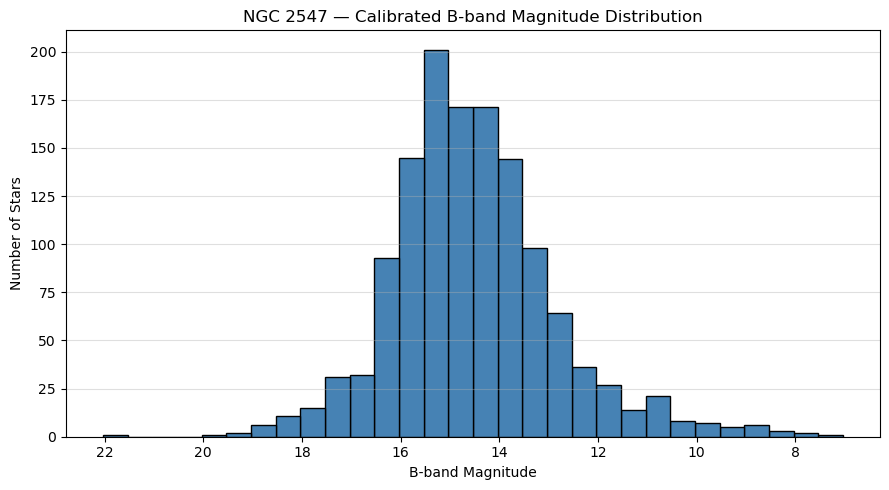

In [23]:
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
import numpy as np

# ── Helper functions ──────────────────────────────────────────────────────────

def net_flux(data, pos, r_ap=8.3, r_in=25, r_out=40):
    aperture    = CircularAperture([pos], r=r_ap)
    annulus     = CircularAnnulus([pos], r_in=r_in, r_out=r_out)
    phot        = aperture_photometry(data, aperture)
    bkg_phot    = aperture_photometry(data, annulus)
    bkg_per_pix = bkg_phot['aperture_sum'][0] / annulus.area
    flux_net    = phot['aperture_sum'][0] - bkg_per_pix * aperture.area
    return flux_net, bkg_per_pix

def gaia_to_V(G, G_BP, G_RP):
    """Gaia DR3 → Johnson V (Riello et al. 2021)."""
    a0, a1, a2, a3 = -0.01597, -0.02809, -0.002483, 0.0
    colour = G_BP - G_RP
    return G + a0 + a1*colour + a2*colour**2 + a3*colour**3

def gaia_to_B(G, G_BP, G_RP):
    """Gaia DR3 → Johnson B (Riello et al. 2021)."""
    a0, a1, a2, a3 = 0.01448, 0.72323, -0.01553, 0.0
    colour = G_BP - G_RP
    return G + a0 + a1*colour + a2*colour**2 + a3*colour**3

def BV_from_gaia(G, G_BP, G_RP):
    """Johnson B-V from Gaia colours."""
    return gaia_to_B(G, G_BP, G_RP) - gaia_to_V(G, G_BP, G_RP)

def B_to_seestar_blue(B, BV):
    """Convert Johnson B to expected SeeStar Blue magnitude.
    SeeStar Blue = B - 0.63*(B-V) + 0.01  (NMAD=0.033)
    """
    return B - 0.63 * BV + 0.01

def seestar_blue_to_B(blue_mag, BV):
    """Convert measured SeeStar Blue magnitude back to Johnson B."""
    return blue_mag + 0.63 * BV - 0.01

# ── Reference star ────────────────────────────────────────────────────────────

G_BP_ref, G_ref, G_RP_ref = 10.787, 10.702, 10.568
x_ref, y_ref               = 560.3, 90.4

B_ref_johnson = gaia_to_B(G_ref, G_BP_ref, G_RP_ref)
BV_ref        = BV_from_gaia(G_ref, G_BP_ref, G_RP_ref)
blue_ref      = B_to_seestar_blue(B_ref_johnson, BV_ref)

F_ref, bkg_ref = net_flux(sci_data, (x_ref, y_ref))

print("=== Reference Star ===")
print(f"  Johnson B:          {B_ref_johnson:.3f}")
print(f"  B-V:                {BV_ref:.3f}")
print(f"  SeeStar Blue:       {blue_ref:.3f}")
print(f"  Net flux:           {F_ref:.1f} ADU")
print(f"  Background/pixel:   {bkg_ref:.3f} ADU")

# ── Calibrate all sources ─────────────────────────────────────────────────────

maglist  = []   # Calibrated Johnson B magnitudes
bluelist = []   # SeeStar Blue instrumental magnitudes

# Assume a typical young open cluster colour B-V ~ 0.5 → offset = -0.63*0.5+0.01 = -0.305
# Adjust BV_assumed if your cluster's population differs
BV_assumed        = 0.5
blue_to_B_offset  = 0.63 * BV_assumed - 0.01   # = +0.305

for obj in phot_table:
    flux_raw = obj['aperture_sum']
    if flux_raw > 0 and F_ref > 0:
        blue_mag = blue_ref - 2.5 * np.log10(flux_raw / F_ref)
        bluelist.append(blue_mag)
        maglist.append(blue_mag + blue_to_B_offset)
    else:
        bluelist.append(np.nan)
        maglist.append(np.nan)

maglist  = np.array(maglist)
bluelist = np.array(bluelist)

# ── Summary ───────────────────────────────────────────────────────────────────

valid = maglist[np.isfinite(maglist) & (maglist > 0) & (maglist < 25)]
print(f"\n=== Calibration Summary ===")
print(f"  Total sources:         {len(maglist)}")
print(f"  Valid B magnitudes:    {len(valid)}")
print(f"  Magnitude range:       {valid.min():.2f} to {valid.max():.2f}")
print(f"  Assumed B-V:           {BV_assumed:.2f}  (adjust if needed)")

# ── Print first 20 results ────────────────────────────────────────────────────

print(f"\n{'idx':>5} {'x':>8} {'y':>8} {'raw_flux':>12} {'Blue':>8} {'B_mag':>8}")
print("-" * 55)
for i in range(min(20, len(phot_table))):
    print(f"{i:>5} {phot_table['xcenter'][i].value:>8.2f} "
          f"{phot_table['ycenter'][i].value:>8.2f} "
          f"{phot_table['aperture_sum'][i]:>12.1f} "
          f"{bluelist[i]:>8.3f} {maglist[i]:>8.3f}")

# ── Histogram ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

bin_edges = np.arange(np.nanmin(valid), np.nanmax(valid) + 0.5, 0.5)
plt.figure(figsize=(9, 5))
plt.hist(valid, bins=bin_edges, edgecolor='black', color='steelblue')
plt.xlabel('B-band Magnitude')
plt.ylabel('Number of Stars')
plt.title('NGC 2547 — Calibrated B-band Magnitude Distribution')
plt.gca().invert_xaxis()
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig("calibrated_B_band_magnitude.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
import pandas as pd
import numpy as np

df_b = pd.DataFrame({
    "x":            phot_table['xcenter'].value,
    "y":            phot_table['ycenter'].value,
    "raw_flux":     phot_table['aperture_sum'],
    "Blue":    bluelist,    # SeeStar Blue instrumental magnitude
    "B_mag":    maglist      # Calibrated Johnson B
})
df_b = df_b.replace([np.inf, -np.inf], np.nan)
df_b.to_csv("maglist_B_catalog.csv", index=False)
print(f"Saved {len(df_b)} sources to maglist_B_catalog.csv")
print(df_b.head())


Saved 1358 sources to maglist_B_catalog.csv
            x         y      raw_flux       Blue      B_mag
0    4.927159  1.644596    423.042072  15.687667  15.992667
1   56.952530  2.350410   3806.568531  13.302291  13.607291
2  229.253200  0.988306  95919.777619   9.798855  10.103855
3  261.458595  0.803134   3182.281280  13.496779  13.801779
4  407.393861  4.421757   2807.337121  13.632889  13.937889


# Calibrating and Cataloguing Red band  

In [51]:
r_combined = CCDData.read("r_NGC_2547_cropped.fits", unit="adu")
print("Loaded r_combined successfully")

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Loaded r_combined successfully


In [15]:
from astroquery.astrometry_net import AstrometryNet
from astropy.io import fits

ast = AstrometryNet()
ast.api_key = 'rahhejaruebqmxrg'  # Get from nova.astrometry.net

# Submit image for plate solving
wcs_header = ast.solve_from_image('r_NGC_2547_cropped.fits', force_image_upload=True)

# Add WCS to original FITS file
with fits.open('r_NGC_2547_cropped.fits', mode='update') as hdul:
    hdul[0].header.update(wcs_header)
    hdul.flush()

print("WCS added successfully!")

Solving..............................................................................WCS added successfully!


In [16]:
scim=CCDData.read("r_NGC_2547_cropped.fits", unit="adu")   # Read the image

w = scim.wcs                                      # Read the World Coordinate System
print(w)

med=np.median(scim.data)                          # Median pixel value
scim.data=scim.data-med                           # Use the median for the sky subtraction
mean, median, std = astropy.stats.sigma_clipped_stats(scim.data, sigma=3.0, maxiters=5)    
print('Image stats (mean, median and standard deviation):', mean,median,std)

segimage=detect_sources(scim.data, 2.00*std, 9, connectivity=4, mask=None)

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 122.35301058 -48.8902715142 
CRPIX : 587.782646179 -116.988124847 
PC1_1 PC1_2  : -0.000595785991798 0.000280943570293 
PC2_1 PC2_2  : -0.000280968045784 -0.000595799946249 
CDELT : 1.0 1.0 
NAXIS : 1080  700
Image stats (mean, median and standard deviation): -0.21671688556671143 -0.573174774646759 7.375021457672119


/opt/homebrew/Caskroom/miniforge/base/envs/obsastro2024/lib/python3.9/site-packages/astropy/wcs/wcs.py:3124: RuntimeWarning: cdelt will be ignored since cd is present
  description.append(s.format(*self.wcs.cdelt))


In [17]:
outfile="segimage_r.fits"                # Set the output file name
hdu=fits.PrimaryHDU(segimage)          # Define a FITS header for this data
# Convert WCS to header format
wcsheader = w.to_header(relax=True)
hdu.header.extend(wcsheader)
hdu.writeto(outfile, overwrite=True)   # Write the output and overwrite existing files if needed. 


In [18]:

with fits.open('r_NGC_2547_cropped.fits') as hdul:    
    sci_data   = hdul[0].data.astype(float).copy()
    sci_header = hdul[0].header

with fits.open('segimage_r.fits') as hdul:
    seg_data = hdul[0].data.copy()

w = WCS(sci_header)
sci_data -= np.median(sci_data)
_, _, std = astropy.stats.sigma_clipped_stats(sci_data, sigma=3.0, maxiters=5)

segmap       = SegmentationImage(seg_data)
source_table = SourceCatalog(sci_data, segmap, wcs=w)

# Aperture photometry on all detected sources 
positions = []
valid_sources = []   # keep track of which sources had valid centroids

for obj in source_table:
    x, y = obj.centroid[0], obj.centroid[1]
    if np.isfinite(x) and np.isfinite(y):   # skip NaN centroids
        positions.append((x, y))
        valid_sources.append(obj)

print(f"Total sources in segmap:       {len(source_table)}")
print(f"Sources with valid centroids:  {len(positions)}")

apertures  = CircularAperture(positions, r=8.3)
phot_table = aperture_photometry(sci_data, apertures)

print("\nFirst 10 rows of photometry table:")
print(phot_table[:10])
print("\nColumn names:", phot_table.colnames)

#  Gaia query 
ra_field  = 122.353125759
dec_field = -48.8904062838

coord  = SkyCoord(ra=ra_field, dec=dec_field, unit='deg', frame='icrs')
radius = u.Quantity(0.25, u.deg)

Gaia.ROW_LIMIT = 5000
print("\nQuerying Gaia DR3...")
j = Gaia.cone_search(coordinate=coord, radius=radius)
time.sleep(3)
r = j.get_results()

mask = (r['phot_g_mean_mag']  > 0) & (r['phot_g_mean_mag']  < 30) & \
       (r['phot_bp_mean_mag'] > 0) & (r['phot_bp_mean_mag'] < 30) & \
       (r['phot_rp_mean_mag'] > 0) & (r['phot_rp_mean_mag'] < 30)
r = r[mask]
r.sort('phot_g_mean_mag')

nrows, ncols = sci_data.shape
gaia_coords  = SkyCoord(ra=r['ra'], dec=r['dec'], unit='deg', frame='icrs')
px, py       = w.world_to_pixel(gaia_coords)

in_image = (px > 20) & (px < ncols-20) & (py > 20) & (py < nrows-20)
r  = r[in_image]
px = px[in_image]
py = py[in_image]
print(f"Gaia sources inside image footprint: {len(r)}")

# Matching each Gaia star to nearest source in phot_table 
phot_x = np.array(phot_table['xcenter'])
phot_y = np.array(phot_table['ycenter'])

print("\n Candidate Reference stars (G < 12)")
print(f"{'#':<4} {'RA':>12} {'Dec':>12} {'G_BP':>6} {'G':>6} {'G_RP':>6}  "
      f"{'x_pix':>7} {'y_pix':>7}  {'dist':>5} {'aperture_sum':>14}")
print("-" * 90)
count = 0
for i in range(len(r)):
    if r['phot_g_mean_mag'][i] < 12:
        dists   = np.sqrt((phot_x - px[i])**2 + (phot_y - py[i])**2)
        nearest = int(np.argmin(dists))
        flux    = phot_table['aperture_sum'][nearest]
        print(f"{count:<4} {r['ra'][i]:>12.5f} {r['dec'][i]:>12.5f} "
              f"{r['phot_bp_mean_mag'][i]:>6.3f} {r['phot_g_mean_mag'][i]:>6.3f} "
              f"{r['phot_rp_mean_mag'][i]:>6.3f}  {px[i]:>7.1f} {py[i]:>7.1f}  "
              f"{dists[nearest]:>5.1f} {flux:>14.1f}")
        count += 1
        if count >= 60:
            break

print("\n Candidate Faint stars (15 < G < 18) ")
print(f"{'#':<4} {'RA':>12} {'Dec':>12} {'G_BP':>6} {'G':>6} {'G_RP':>6}  "
      f"{'x_pix':>7} {'y_pix':>7}  {'dist':>5} {'aperture_sum':>14}")
print("-" * 90)
count = 0
for i in range(len(r)):
    g = r['phot_g_mean_mag'][i]
    if 15 < g < 18:
        dists   = np.sqrt((phot_x - px[i])**2 + (phot_y - py[i])**2)
        nearest = int(np.argmin(dists))
        flux    = phot_table['aperture_sum'][nearest]
        print(f"{count:<4} {r['ra'][i]:>12.5f} {r['dec'][i]:>12.5f} "
              f"{r['phot_bp_mean_mag'][i]:>6.3f} {g:>6.3f} "
              f"{r['phot_rp_mean_mag'][i]:>6.3f}  {px[i]:>7.1f} {py[i]:>7.1f}  "
              f"{dists[nearest]:>5.1f} {flux:>14.1f}")
        count += 1
        if count >= 60:
            break

Total sources in segmap:       1358
Sources with valid centroids:  1358

First 10 rows of photometry table:
 id      xcenter             ycenter          aperture_sum   
           pix                 pix                           
--- ------------------ ------------------- ------------------
  1  4.927158519008853  1.6445959159596963  423.0420716843233
  2 56.952530040029245   2.350409738141945 3806.5685310610943
  3 229.25319954102287   0.988306199644731  95919.77761871654
  4  261.4585954124917  0.8031335149180743  3182.281279927893
  5  407.3938607351737   4.421757024390935  2807.337121324131
  6  425.3617591041677  0.5210627657844816 1937.8913466480365
  7  443.6821438441237 0.49752042298636684  1697.150236084585
  8 487.58951289455234  0.3531516276029936 164.17069954137708
  9   792.053424552379  1.5339765953837232  3637.327324676461
 10  880.1683513191706  0.7050250865595729 163.74791790753522

Column names: ['id', 'xcenter', 'ycenter', 'aperture_sum']

Querying Gaia DR3...
Gaia

In [19]:

a0 = -0.12879
a1 =  0.24662
a2 = -0.027464
a3 = -0.049465

def gaia_to_R(G, G_BP, G_RP):
    colour = G_BP - G_RP
    return G + a0 + a1*colour + a2*colour**2 + a3*colour**3

# Reference star
G_BP_ref = 10.787
G_ref    = 10.702
G_RP_ref = 10.568
F_ref    = 54261.0

# Faint star 
  
G_BP_faint = 15.824
G_faint    = 15.063
G_RP_faint = 14.214 
F_faint    = 1390.2

R_ref        = gaia_to_R(G_ref,   G_BP_ref,   G_RP_ref)
R_faint_gaia = gaia_to_R(G_faint, G_BP_faint, G_RP_faint)

print(" Reference Star")
print(f"  GBP-GRP colour:         {G_BP_ref - G_RP_ref:.3f}")
print(f"  Calibrated R magnitude: {R_ref:.3f}")
print(f"  Measured flux (F_ref):  {F_ref:.1f} ADU")

print("\n Faint Star ")
print(f"  GBP-GRP colour:              {G_BP_faint - G_RP_faint:.3f}")
print(f"  Gaia-calibrated R magnitude: {R_faint_gaia:.3f}")
print(f"  Measured flux:               {F_faint:.1f} ADU")

# ── Sanity check ──────────────────────────────────────────────────────────────
R_faint_measured = R_ref - 2.5 * np.log10(F_faint / F_ref)

print("\ Sanity Check ")
print(f"  R (from image photometry): {R_faint_measured:.3f}")
print(f"  R (from Gaia DR3 formula): {R_faint_gaia:.3f}")
print(f"  Difference:                {abs(R_faint_measured - R_faint_gaia):.3f} mag")
if abs(R_faint_measured - R_faint_gaia) < 0.5:
    print("  Good agreement")
else:
    print("  Large discrepancy")

 Reference Star
  GBP-GRP colour:         0.219
  Calibrated R magnitude: 10.625
  Measured flux (F_ref):  54261.0 ADU

 Faint Star 
  GBP-GRP colour:              1.610
  Gaia-calibrated R magnitude: 15.054
  Measured flux:               1390.2 ADU
\ Sanity Check 
  R (from image photometry): 14.604
  R (from Gaia DR3 formula): 15.054
  Difference:                0.450 mag
  Good agreement


=== Reference Star ===
  Cousins R:          10.625
  SeeStar Red:        10.666
  Net flux:           39516.7 ADU
  Background/pixel:   67.959 ADU

=== Calibration Summary ===
  Total sources:         1358
  Valid R magnitudes:    1316
  Magnitude range:       6.53 to 21.40

  idx        x        y     raw_flux      Red    R_mag
-------------------------------------------------------
    0     4.93     1.64        423.0   15.592   15.493
    1    56.95     2.35       3806.6   13.207   13.107
    2   229.25     0.99      95919.8    9.703    9.604
    3   261.46     0.80       3182.3   13.401   13.302
    4   407.39     4.42       2807.3   13.537   13.438
    5   425.36     0.52       1937.9   13.940   13.840
    6   443.68     0.50       1697.2   14.084   13.984
    7   487.59     0.35        164.2   16.620   16.520
    8   792.05     1.53       3637.3   13.256   13.157
    9   880.17     0.71        163.7   16.623   16.523
   10   985.17     0.37        398.1   15.658   15.559
   11  

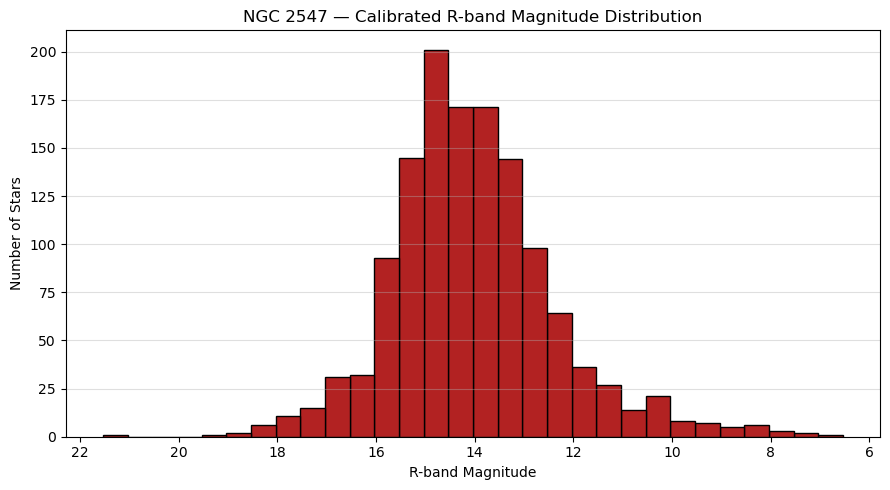

In [20]:
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
import numpy as np

# Helper functions 
def net_flux(data, pos, r_ap=8.3, r_in=25, r_out=40):
    aperture    = CircularAperture([pos], r=r_ap)
    annulus     = CircularAnnulus([pos], r_in=r_in, r_out=r_out)
    phot        = aperture_photometry(data, aperture)
    bkg_phot    = aperture_photometry(data, annulus)
    bkg_per_pix = bkg_phot['aperture_sum'][0] / annulus.area
    flux_net    = phot['aperture_sum'][0] - bkg_per_pix * aperture.area
    return flux_net, bkg_per_pix

def gaia_to_R(G, G_BP, G_RP):
    """Gaia DR3 → Cousins R using official colour transformation.
    R = G + a0 + a1*(GBP-GRP) + a2*(GBP-GRP)^2 + a3*(GBP-GRP)^3
    Valid for GBP-GRP in range 0.0 to 2.5  (Riello et al. 2021)
    """
    a0, a1, a2, a3 = -0.12879, 0.24662, -0.027464, -0.049465
    colour = G_BP - G_RP
    return G + a0 + a1*colour + a2*colour**2 + a3*colour**3

def VR_from_gaia(G_BP, G_RP):
    """Approximate Cousins V-R from Gaia colours."""
    return 0.61 * (G_BP - G_RP) - 0.03

def R_to_seestar_red(R, G_BP, G_RP):
    """Convert Cousins R to expected SeeStar Red magnitude.
    SeeStar Red = R + 0.20*(V-R) + 0.02
    """
    VR = VR_from_gaia(G_BP, G_RP)
    return R + 0.20 * VR + 0.02

def seestar_red_to_R(red_mag, G_BP, G_RP):
    """Convert measured SeeStar Red magnitude back to Cousins R."""
    VR = VR_from_gaia(G_BP, G_RP)
    return red_mag - 0.20 * VR - 0.02

# Reference star
G_BP_ref, G_ref, G_RP_ref = 10.787, 10.702, 10.568
x_ref, y_ref               = 560.3, 90.4

R_ref_cousins  = gaia_to_R(G_ref, G_BP_ref, G_RP_ref)
red_ref        = R_to_seestar_red(R_ref_cousins, G_BP_ref, G_RP_ref)
F_ref, bkg_ref = net_flux(sci_data, (x_ref, y_ref))

print("=== Reference Star ===")
print(f"  Cousins R:          {R_ref_cousins:.3f}")
print(f"  SeeStar Red:        {red_ref:.3f}")
print(f"  Net flux:           {F_ref:.1f} ADU")
print(f"  Background/pixel:   {bkg_ref:.3f} ADU")

# Calibrate all sources
maglist  = []   # Calibrated R magnitudes
redlist  = []   # SeeStar Red magnitudes (before R correction)

for obj in phot_table:
    flux_raw = obj['aperture_sum']
    if flux_raw > 0 and F_ref > 0:
        red_mag = red_ref - 2.5 * np.log10(flux_raw / F_ref)
        redlist.append(red_mag)
        # Assume typical cluster colour GBP-GRP ~ 0.7 → V-R ~ 0.40
        red_to_R_offset = -(0.20 * (0.61 * 0.7 - 0.03) + 0.02)   # = -0.093
        maglist.append(red_mag + red_to_R_offset)
    else:
        redlist.append(np.nan)
        maglist.append(np.nan)

maglist = np.array(maglist)
redlist = np.array(redlist)

# Summary 
valid = maglist[np.isfinite(maglist) & (maglist > 0) & (maglist < 25)]
print(f"\n=== Calibration Summary ===")
print(f"  Total sources:         {len(maglist)}")
print(f"  Valid R magnitudes:    {len(valid)}")
print(f"  Magnitude range:       {valid.min():.2f} to {valid.max():.2f}")

# Print first 20 results 
print(f"\n{'idx':>5} {'x':>8} {'y':>8} {'raw_flux':>12} {'Red':>8} {'R_mag':>8}")
print("-" * 55)
for i in range(min(20, len(phot_table))):
    print(f"{i:>5} {phot_table['xcenter'][i].value:>8.2f} "
          f"{phot_table['ycenter'][i].value:>8.2f} "
          f"{phot_table['aperture_sum'][i]:>12.1f} "
          f"{redlist[i]:>8.3f} {maglist[i]:>8.3f}")

# Histogram 
import matplotlib.pyplot as plt

bin_edges = np.arange(np.nanmin(valid), np.nanmax(valid) + 0.5, 0.5)

plt.figure(figsize=(9, 5))
plt.hist(valid, bins=bin_edges, edgecolor='black', color='firebrick')
plt.xlabel('R-band Magnitude')
plt.ylabel('Number of Stars')
plt.title('NGC 2547 — Calibrated R-band Magnitude Distribution')
plt.gca().invert_xaxis()
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig("calibrated_R_band_magnitude.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
import pandas as pd
import numpy as np

df_r = pd.DataFrame({
    "x":       phot_table['xcenter'].value,
    "y":       phot_table['ycenter'].value,
    "raw_flux": phot_table['aperture_sum'],
    "Red":  redlist,
    "R_mag":    maglist
})

df_r = df_r.replace([np.inf, -np.inf], np.nan)
df_r.to_csv("maglist_R_catalog.csv", index=False)
